# 2025 DL lab2: Binary Classification

This assignment aims to work you through the core concepts in implementation a binary classifier.

## Logistic Regression

Logistic regression predicts the probability that an event could occur and typically is used to perform binary classification.

In the first two parts of this assignment, we will cover:
* PyTorch: Tensor operations
* Machine Learning: Data preprocessing, logistic Regression, gradient descent,

This assignment will walk you through implementing a logistic regression model that classifies whether a person is rich or poor using the UCI adult income dataset in PyTorch.

**Pytorch auto grad is not allowed**

Note that **You ARE NOT allowed to remove any assertions.**

##  Versions of used packages

We will check PyTorch version to make sure everything work properly.

I use `python 3.12.11`, `torch==2.8.0+cu129` and `torchvision==0.23.0+cu129`

In [63]:
!python --version
import torch
import torchvision
print('torch', torch.__version__)
print('torchvision', torchvision.__version__)


Python 3.13.5
torch 2.8.0+cu129
torchvision 0.23.0+cu129


## Preparing Data

### Loading Data

We use [adult income](https://www.kaggle.com/wenruliu/adult-income-dataset) dataset from UCI machine learning repository.  

**Abstract**  

Given an individual’s education level, age, gender, occupation, and etc, we want to predict his or her income level.   

**Metadata**  
Number of attributes: 14  
- income: >50K, <=50K
- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous.
- capital-loss: continuous.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

There are 4 csv files.


* X_train: training data
* X_test: training data labels
* Y_train: test data
* Y_test: test data labels.

Each row in X has 106 fields.
Each row Y represents the true label of 0 (poor) and 1 (rich).  

Or you can load train.csv raw data and do your pre-processing.

In [64]:
import numpy as np
import pandas as pd
#change this dir to your dataroot
data_root = "./"

X_train_raw = pd.read_csv(data_root+'data/X_train.csv')
Y_train_raw = pd.read_csv(data_root+'data/Y_train.csv')
X_test_raw = pd.read_csv(data_root+'data/X_test.csv')
Y_test_raw = pd.read_csv(data_root+'data/Y_test.csv')

X_train_raw.head()
X_train_value = X_train_raw.values
Y_train_value = Y_train_raw.values
X_test_value = X_test_raw.values
Y_test_value = Y_test_raw.values

You may already notice that there are two datasets.   One is "training set", and the other is "test set".  
The training set is like **homework of model**. A model uses the training set to learn.  
The testing set is like **quiz of model**. A learned model is tested on the testing set for evaluating how good a model is.



### Pre-Processing Data

In a data science process, data cleansing usually cost the most of time.  
Dirty data will cause overfitting or make us ignore those important features. Even if you don't have correct cleansing and format, your model can't run anymore.

In [65]:
import torch
#new version of torch transform
from torchvision.transforms import v2
############################################################################
#              TODO: Implement custum data preprocess pipeline             #
############################################################################
class STDNorm:
    def __call__(self, x: torch.Tensor):
        """
        x: torch.Tensor, shape(batch_size, feature_dim). input data.
        """
        mu = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True)
        return (x-mu) / (std + 1e-8) 

#define data preprocess pipeline:
datapipeline = v2.Compose([
    #numpy ndarray should change to torch.Tensor first
    v2.ToTensor(),
    STDNorm(),
])
############################################################################
#                             END OF YOUR CODE                             #
############################################################################

e:\project\deeplearning_HW2\deeplearning_project\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [66]:
from torch.utils.data import Dataset, DataLoader
class MyDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.transform = transform
        self.x = torch.from_numpy(x).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        data = self.x[idx]
        label = self.y[idx]
        if self.transform is not None:
            data = self.transform(data)
        return data, label

trainset = MyDataset(X_train_value, Y_train_value,datapipeline)
testset = MyDataset(X_test_value, Y_test_value, datapipeline)
print("trainset size: {}, testset size: {}".format(len(trainset), len(testset)))
assert len(trainset) == 32561, "trainset size should be 32561 but got {}".format(len(trainset))
assert len(testset) == 16281, "testset size should be 16281 but got {}".format(len(testset))
print("feature dim: {}, label dim: {}".format(trainset[0][0].shape, trainset[0][1].shape))

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=0)

trainset size: 32561, testset size: 16281
feature dim: torch.Size([106]), label dim: torch.Size([1])


Because the data used to train a deep model may be large, you could not load the model and the whole dataset into memory (GPU or RAM) at the same time.  
So, we split the data into mini-batches.

We have prepared the data.  
Let's develop a logistic regression model.

# Implement Logistic Regression from Scratch

### Activation Functions

Logistic Regression uses a logistic function (or called a sigmoid function) to turn a real value into a probability (a value between zero and one).
$$
\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}
$$
Below depicts the sigmoid function.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/8/88/Logistic-curve.svg/640px-Logistic-curve.svg.png)

*Source: wikipedia*

In [67]:
import torch
def sigmoid(z):
    '''
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or torch.Tensor of any size.

    Return:
    s -- torch.Tensor, sigmoid(z)
    '''
    if not isinstance(z, torch.Tensor):
        z = torch.tensor(z, dtype=torch.float)
    ############################################################################
    # TODO: Implement sigmoid (or called logistic) function                     #
    ############################################################################
    out = 1 / (1 + torch.exp(-z))
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
    # prevent out is Inf or -Inf
    out = torch.clamp(out, 1e-6, 1-1e-6)
    return out

s_t1 = sigmoid(0)
s_t2 = sigmoid(2)
s_t3 = sigmoid(-1)
print('sigmoid(0)  =', s_t1)
print('sigmoid(2)  =', s_t2)
print('sigmoid(-1) =', s_t3)
msg = 'Your sigmoid: {} isn\'t correct'
assert (s_t1 - 0.5) < 0.001, msg.format(sigmoid(0))
assert (s_t2 - 0.8808) < 0.001, msg.format(sigmoid(2))
assert (s_t3 - 0.2689) < 0.001, msg.format(sigmoid(-1))

sigmoid(0)  = tensor(0.5000)
sigmoid(2)  = tensor(0.8808)
sigmoid(-1) = tensor(0.2689)


Here is derivative of sigmoid function

![](https://media.geeksforgeeks.org/wp-content/uploads/20250202000803455713/Sigmoid-and-its-derivative.png)

*Source: web*



## Backpropagation
Backpropagation is the core algorithm used to train neural networks. It's essentially a way to calculate how much each weight and bias in the network contributed to the overall error, so we can adjust them to improve performance.  
Backpropagation uses the chain rule from calculus to efficiently compute gradients.  
For example:  
![](https://miro.medium.com/v2/resize:fit:1380/1*mudCF1PDeBlErRNOPXD24Q.jpeg)


In practice, we will store local gradient in each layer during forward process.


Define activation function classes, to put forward and backward methods together.

In [68]:
class Sigmoid:
    def __init__(self):
        self.out = None
    def forward(self, x):
        '''
        Compute the sigmoid of x

        Arguments:
        x -- torch.Tensor
        '''
        self.out = sigmoid(x)
        return self.out

    def backward(self, upstream_grad):
        '''
        Compute the derivative of sigmoid of x

        Arguments:
        upstream_grad -- torch.Tensor
        '''
        ############################################################################
        # TODO: Implement sigmoid (or called logistic) function backward           #
        ############################################################################
        local_grad = self.out * (1 - self.out)
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        downstream_grad = upstream_grad * local_grad
        return downstream_grad

Another activation function widely used in NN is Relu, which is usualy place after each linear layer.
![](https://sebastianraschka.com/images/faq/relu-derivative/relu_3.png)

Relu is a partially differentiable function.  
**Derivative = 0 when x < 0.**  
**Derivative = 1 when x > 0.**  

In [69]:
class Relu:
    def __init__(self):
        self.ori_tensor = None
    def forward(self, x):
        '''
        Compute the relu of x

        Arguments:
        x -- torch.Tensor
        '''
        self.ori_tensor = x.clone()
        ############################################################################
        # TODO: Implement relu function forward.                                   #
        ############################################################################
        #hint use index condition to set elements which are negative to zero
        out = self.ori_tensor.clone()
        out[out < 0] = 0
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        return out
    def backward(self, upstream_grad):
        '''
        Compute the derivative of relu of x

        Arguments:
        upstream_grad -- torch.Tensor
        '''
        ############################################################################
        # TODO: Implement relu function backward.                                  #
        ############################################################################
        #hint:use index condition to set elements which are negative to zero, and which are positive to 1.
        local_grad = torch.zeros_like(self.ori_tensor)
        local_grad[self.ori_tensor > 0] = 1.0
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        downstream_grad = upstream_grad * local_grad
        return downstream_grad

test_relu = Relu()
test_input = torch.tensor([[-2.0, -1.0, 0.0, 1.0, 2.0]], requires_grad=True)
relu_output = test_relu.forward(test_input)
print(f"Input: {test_input}")
print(f"ReLU output: {relu_output}")
upstream_grad = torch.ones_like(relu_output)
downstream_grad = test_relu.backward(upstream_grad)
print(f"Upstream gradient: {upstream_grad}")
print(f"Downstream gradient: {downstream_grad}")
expected_grad = torch.tensor([[0.0, 0.0, 0.0, 1.0, 1.0]])
assert torch.allclose(downstream_grad, expected_grad), f"Expected {expected_grad}, got {downstream_grad}"

Input: tensor([[-2., -1.,  0.,  1.,  2.]], requires_grad=True)
ReLU output: tensor([[0., 0., 0., 1., 2.]], grad_fn=<IndexPutBackward0>)
Upstream gradient: tensor([[1., 1., 1., 1., 1.]])
Downstream gradient: tensor([[0., 0., 0., 1., 1.]])


### Linear layer

A linear layer (or fully connected layer) performs a linear transformation using matrix multiplication and bias addition.
![](https://miro.medium.com/v2/resize:fit:1400/format:webp/0*l0u3jkkue3Ry44cC.gif)

In [70]:

class LinearLayer:
    def __init__(self, input_dim, output_dim) -> None:
        self.local_grad_weight = None
        self.local_grad_bias = None
        self.local_grad_input = None
        ############################################################################
        # TODO: Define how you create and initial your weights and bias            #
        self.w = torch.empty(input_dim, output_dim)
        torch.nn.init.kaiming_uniform_(self.w, a=math.sqrt(5))
        self.b = torch.zeros(output_dim)
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        self.dw = torch.zeros_like(self.w)
        self.db = torch.zeros_like(self.b)
    def forward(self, x: torch.Tensor):
        """Forward pass for the linear layer.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim).
        """
        assert self.w.shape[0] == x.shape[1], "input feature dim not match"
        assert len(x.shape) == 2, "input should be 2-dim tensor (batch_size, feature_dim)"
        ############################################################################
        # TODO: Implement Linear layer forward and caculate local gradients.       #
        ############################################################################
        self.x = x.clone()
        output = x @ self.w + self.b
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        return output
    def backward(self, upstream_grad):
        """Backward pass for the linear layer.

        Args:
            upstream_grad (torch.Tensor): Gradient of the loss with respect to the output of the layer, of shape (batch_size, output_dim).

        Returns:
            torch.Tensor: Gradient of the loss with respect to the input of the layer, of shape (batch_size, input_dim).
        """
        assert len(upstream_grad.shape) == 2, "upstream grad should be 2-dim tensor (batch_size, feature_dim)"
        ############################################################################
        # TODO: Implement backward pass for linear layer and compute gradients.   #
        ############################################################################
        self.dw = self.x.T @ upstream_grad
        self.db = torch.sum(upstream_grad, dim=0)
        downstream_grad = upstream_grad @ self.w.T
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        assert self.db.shape == self.b.shape, 'Shape of db is incorrect.'
        assert self.dw.shape == self.w.shape, 'Shape of dw is incorrect.'
        return downstream_grad


### Loss Function

Many machine learning applications use the cross-entropy loss as described in class. This loss can be directly derived from information theoretic considerations, which measures the differences between two probability distributions.
In this assignment, we will use the binary cross entropy loss for binary classification.
![](https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508)

In [71]:
class BinaryCrossEntropy:
    def __init__(self, reduction='mean'):
        self.local_grad = None
        self.batch_size = None
        self.out = None
        self.reduction = reduction
        if reduction not in ['mean', 'sum']:
            raise ValueError("reduction should be 'mean' or 'sum'")
    def forward(self, y_true, y_pred):
        '''
        Compute the binary cross entropy of inputs.
        (You should compute average whithin batch)

        Arguments:
        y_true -- torch.Tensor, True data with shape(batch_size, 1).
        y_pred -- torch.Tensor, Predicted data with shape(batch_size, 1)

        Return:
        loss -- torch.Tensor with shape(1,)
        '''
        assert y_true.shape == y_pred.shape, "y_true shape should be {}, but got {}".format(y_pred.shape, y_true.shape)
        self.batch_size = y_true.shape[0]
        ########################################################################
        #                           Your code here                             #
        ########################################################################
        '''
        Compute local gradient here and store it in self.local_grad
        hint: You only need to compute the local gradient for y_pred
        p.s. If you implement reduction 'mean', don't forget to divide the local gradient by batch_size.
        '''
        epsilon = 1e-8
        y_pred_clipped = torch.clamp(y_pred, epsilon, 1 - epsilon)
        # L = -[y*log(p) + (1-y)*log(1-p)]
        loss = -(y_true * torch.log(y_pred_clipped) + (1 - y_true) * torch.log(1 - y_pred_clipped))
        # dL/dp = (p-y) / (p*(1-p))
        self.local_grad = (y_pred_clipped - y_true) / (y_pred_clipped * (1 - y_pred_clipped))
        if self.reduction == 'mean':
            self.local_grad = self.local_grad / self.batch_size
        
        ########################################################################
        #                           End of your code                           #
        ########################################################################
        assert self.local_grad.shape == y_true.shape, "local grad shape should be{}, but got {}".format(y_true.shape, self.local_grad.shape)
        if self.reduction == 'mean':
            loss = loss.mean()
        elif self.reduction == 'sum':
            loss = loss.sum()
        return loss
    def backward(self):
        '''
        There is no upstream gradient for loss layer, so you only need to return the local gradient
        Return:
        self.local_grad -- torch.Tensor with shape(batch_size, 1)
        '''
        return self.local_grad


test_bce = BinaryCrossEntropy(reduction='mean')
# Fix the test to use proper shapes
test_y_true = torch.tensor([[1], [1], [1]], dtype=torch.float32)
test_y_pred = torch.tensor([[0.5], [0.8], [0.9]], dtype=torch.float32)
batch_mean_entropy = test_bce.forward(test_y_true, test_y_pred)
print("mean loss in this batch is: {}".format(batch_mean_entropy))
loss_gradient = test_bce.backward()
assert loss_gradient.shape == torch.Size([3, 1]), "loss gradient should be 2-dim tensor with shape(batch_size, 1) but got {}".format(loss_gradient.shape)
print(f"loss_gradient: {loss_gradient}")

mean loss in this batch is: 0.34055042266845703
loss_gradient: tensor([[-0.6667],
        [-0.4167],
        [-0.3704]])


## Logistic Regression Model (4 points)

Let's implement the training algorithm!  

```python
num_epochs = ... # specify the number of epochs to train initialize parameters w, b
for epoch in range(num_epochs):
    shuffle training data
    for each batch:
        forward propagation to get the predictions/outputs
        compute loss
        backward propagation to get the gradients
        update parameters using their gradients
```

You should fill out each methods (init, forward, backward, optimizer...)  
Inputs, outputs, format and description is written in docstring `'''doc string there'''`  
**You are NOT allowed to remove any assertion.**

In [72]:
class LogisticRegression:
    def __init__(self, lr, input_dim, hidden_dim, output_dim):
        '''
        Initialize the learning rate
        Construct a 2-layer MLP using LinearLayer, Relu and Sigmoid class.

        Arguments:
        lr -- float, learning rate (0 < lr <= 1) to control the step of updates.
        feature_dim -- int, the number of features.
        hidden_dim -- int, the number of hidden units.
        output_dim -- int, the number of output units.
        '''
        ########################################################################
        #                           Your code here                             #
        ########################################################################
        self.lr = lr 
        self.linear1 = LinearLayer(input_dim, hidden_dim)
        self.relu = Relu()
        self.linear2 = LinearLayer(hidden_dim, output_dim)
        self.sigmoid = Sigmoid()
        self.layers = [self.linear1, self.relu, self.linear2, self.sigmoid]
        self.criterion = BinaryCrossEntropy(reduction='mean')
        ########################################################################
        #                           End of your code                           #
        ########################################################################

    def forward(self, x):
        '''
        Compute the predicted probability using the w and b for an given input x.
        Store the prediction in self.out, which will be needed in backward pass.

        Arguments:
        x -- torch.Tensor, input data with shape(n, feature_dim).

        Return:
        out -- sigmoid(x * w + b)
        '''
        ########################################################################
        #                           Your code there                            #
        ########################################################################
        out = self.linear1.forward(x)
        out = self.relu.forward(out)
        out = self.linear2.forward(out)
        out = self.sigmoid.forward(out)
        ########################################################################
        #                           End of your code                           #
        ########################################################################
        assert (out > 0).all() and (out < 1).all(), 'Output should > 0 and < 1'
        self.out = out
        return out
    def compute_loss(self, y_true):
        '''
        Compute the loss of the model.

        Arguments:
        y_true -- torch.Tensor, true data with shape(n,).

        Return:
        loss -- torch.Tensor with shape(1,)
        '''
        loss = self.criterion.forward(y_true, self.out)
        return loss
    def backward(self) -> None:
        loss_gradient = self.criterion.backward()
        ########################################################################
        #                           Your code there                            #
        ########################################################################
        grad_input = self.sigmoid.backward(loss_gradient)
        grad_input = self.linear2.backward(grad_input)
        grad_input = self.relu.backward(grad_input)
        _ = self.linear1.backward(grad_input) 
        ########################################################################
        #                           End of your code                           #
        ########################################################################
        return
    def zero_grad(self):
        '''
        Set to zero the gradients of all model parameters.
        '''
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                layer.dw = torch.zeros_like(layer.w)
                layer.db = torch.zeros_like(layer.b)
    def optimize(self):
        raise NotImplementedError


test_model = LogisticRegression(lr=0.01, input_dim=106, hidden_dim=256, output_dim=1)
test_input = next(iter(trainloader))[0]
test_label = next(iter(trainloader))[1]
y_pred = test_model.forward(test_input)
assert y_pred.shape == torch.Size([test_input.shape[0], 1]), "Output shape should be {}, but got {}".format(torch.Size([test_input.shape[0], 1]), y_pred.shape)

## Use SGD as our optimizer

![](https://miro.medium.com/v2/resize:fit:424/format:webp/1*C8PAvTAXukHZ2mZPItwIrg.png)

In [73]:
class LogisticRegressionSGD(LogisticRegression):
    def __init__(self, lr, input_dim, hidden_dim, output_dim):
        super().__init__(lr, input_dim, hidden_dim, output_dim)

    def optimize(self):
        '''
        Update the weights and bias using the gradients stored in each layer.
        '''
        ########################################################################
        #                           Your code there                            #
        ########################################################################
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                layer.w -= self.lr * layer.dw
                layer.b -= self.lr * layer.db
        ########################################################################
        #                           End of your code                           #
        ########################################################################

## Trainer
It's better to encapsulate all the parameters and model into a Trainer Class. So we can redo whole process easily.

In [74]:
def accuracy(y_true, y_pred):
    '''
    Compute the accuracy, the percentage of the correct predictions

    Arguments:
    y_true -- torch.Tensor, True data with shape(n, 1).
    y_pred -- torch.Tensor, Predicted data with shape(n, 1).

    Return:
    acc -- float, accuracy
    '''
    # Ensure both tensors have the same shape
    if y_true.dim() == 2 and y_true.shape[1] == 1:
        y_true = y_true.squeeze(1)
    if y_pred.dim() == 2 and y_pred.shape[1] == 1:
        y_pred = y_pred.squeeze(1)
    ########################################################################
    #                           Your code there                            #
    ########################################################################
    predicted_classes = (y_pred >= 0.5).float()
    correct_predictions = (predicted_classes == y_true).float()
    acc = correct_predictions.mean()
    ########################################################################
    #                           End of your code                           #
    ########################################################################
    return acc.item()

In [75]:
from tqdm import tqdm
class Trainer:
    def __init__(self, model, trainloader, testloader, max_epochs=50, log_interval=5):
        self.model = model
        self.trainloader = trainloader
        self.testloader = testloader
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []
        self.test_loss_list = []
        self.max_epochs = max_epochs
        self.log_interval = log_interval

    def test(self):
        for i, (x, label) in enumerate(self.testloader):
            if i == 0:
                pred_list = []
                label_list = []
            y_pred = self.model.forward(x)
            pred_list.append(y_pred.detach().cpu())
            label_list.append(label.detach().cpu())
        test_acc = accuracy(torch.cat(label_list), torch.cat(pred_list))
        test_loss = self.model.criterion.forward(torch.cat(label_list, dim=0), torch.cat(pred_list, dim=0))
        return test_acc, test_loss

    def train(self):
        for epoch in range(1, self.max_epochs + 1):
            pbar = tqdm(total=len(self.trainloader), desc=f"Epoch {epoch}/{self.max_epochs}")
            loss_list = [] # save train_loss
            pred_list = []
            label_list = []
            for i, (x, label) in enumerate(self.trainloader):
                ########################################################################
                # TODO: Combine all the functions together                             #
                ########################################################################
                # hints:
                # 1. zero the gradients at the beginning of each batch, call zero_grad()
                # 2. get output from forward method, call forward()
                # 3. calculate loss from compute_loss method, call compute_loss()
                # 4. using backward method to calculate gradients, call backward()
                # 5. apply SGD optimize to update model's weights, call optimize()
                # Be careful with the shape of y_pred and label
                self.model.zero_grad()

                y_pred = self.model.forward(x)

                loss = self.model.compute_loss(label) 

                self.model.backward()

                self.model.optimize()
                ########################################################################
                #                         END OF YOUR CODE                             #
                ########################################################################
                pbar.set_postfix({'loss': loss.item()})
                loss_list.append(loss.item())
                pred_list.append(y_pred.detach().cpu())
                label_list.append(label.detach().cpu())
                pbar.update(1)
            pbar.close()
            train_loss = np.mean(loss_list)
            train_acc = accuracy(torch.cat(label_list), torch.cat(pred_list))
            self.train_loss_list.append(train_loss)
            self.train_acc_list.append(train_acc)


            test_acc, test_loss = self.test()
            self.test_acc_list.append(test_acc)
            self.test_loss_list.append(test_loss.item())

            if epoch % self.log_interval == 0:
                print('Epoch: {} \tTrain Loss: {:.6f} \tTrain Acc: {:.6f} \tTest Acc: {:.6f} \tTest Loss: {:.6f}'.format(
                    epoch, train_loss, train_acc, test_acc, test_loss
                ))

    def plot(self):
        import matplotlib.pyplot as plt
        epochs = range(1, len(self.train_loss_list) + 1)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        # Loss plot
        ax1.plot(epochs, self.train_loss_list, 'b-', label='Train Loss', linewidth=2)
        ax1.plot(epochs, self.test_loss_list, 'r-', label='Test Loss', linewidth=2)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Test Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Accuracy plot
        ax2.plot(epochs, self.train_acc_list, 'b-', label='Train Accuracy', linewidth=2)
        ax2.plot(epochs, self.test_acc_list, 'r-', label='Test Accuracy', linewidth=2)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Training and Test Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        final_train_acc = self.train_acc_list[-1]
        final_test_acc = self.test_acc_list[-1]
        print(f"Final Train Accuracy: {final_train_acc:.4f}")
        print(f"Final Test Accuracy: {final_test_acc:.4f}")



## Start training!!
Try to find out the best hyperparameters for training.  
You can also modify model architecture like adding layers.

Epoch 5/20: 100%|██████████| 255/255 [00:01<00:00, 187.92it/s, loss=0.561]


Epoch: 5 	Train Loss: 0.589751 	Train Acc: 0.757532 	Test Acc: 0.779129 	Test Loss: 0.533306


Epoch 10/20: 100%|██████████| 255/255 [00:01<00:00, 184.48it/s, loss=0.543]


Epoch: 10 	Train Loss: 0.535504 	Train Acc: 0.783483 	Test Acc: 0.779068 	Test Loss: 0.571432


Epoch 15/20: 100%|██████████| 255/255 [00:01<00:00, 186.88it/s, loss=0.478]


Epoch: 15 	Train Loss: 0.531330 	Train Acc: 0.786401 	Test Acc: 0.788526 	Test Loss: 0.506950


Epoch 20/20: 100%|██████████| 255/255 [00:01<00:00, 178.98it/s, loss=0.404]


Epoch: 20 	Train Loss: 0.519180 	Train Acc: 0.789196 	Test Acc: 0.785885 	Test Loss: 0.532085


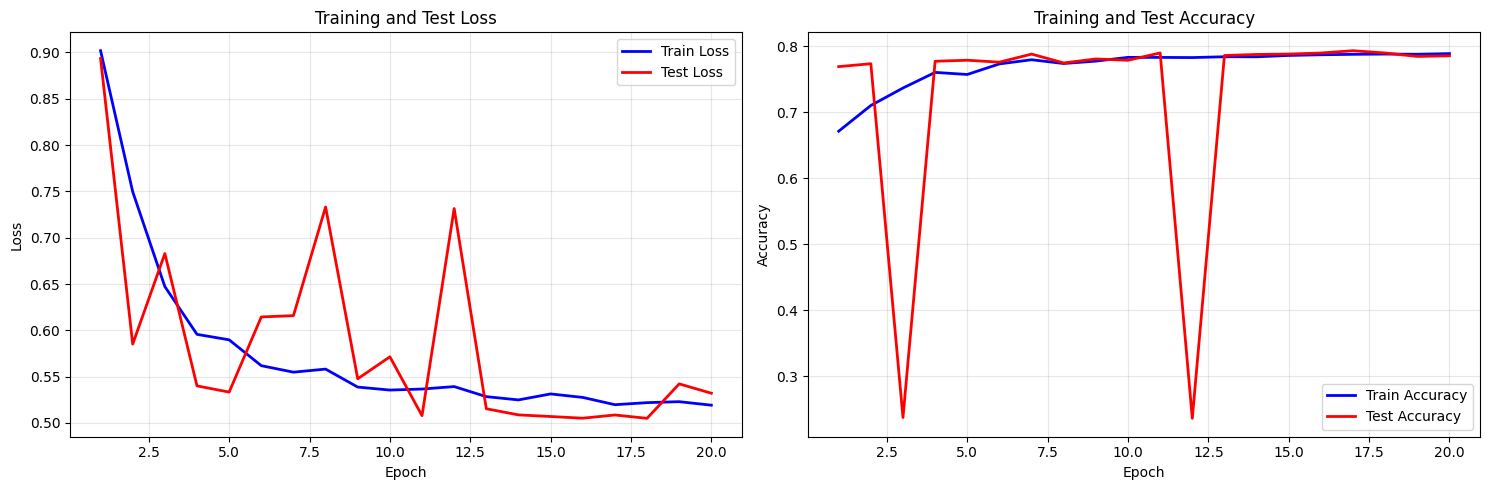

Final Train Accuracy: 0.7892
Final Test Accuracy: 0.7859


In [76]:
################################################################################
#                             Hyperparameters                                 #
# You can modify these hyperparameters to see how they affect the accuracy    #
################################################################################
model = LogisticRegressionSGD(lr=1e-2, input_dim=106, hidden_dim=200, output_dim=1)
trainer = Trainer(model, trainloader, testloader, max_epochs=20, log_interval=5)
trainer.train()
trainer.plot()

Congratulations! You've made it.

## Optimizer with weight decay

In [83]:
class LogisticRegressionWeightDecay(LogisticRegression):
    def __init__(self, lr, input_dim, hidden_dim, output_dim, weight_decay=1e-4):
        '''
        Initialize the learning rate and weight decay
        weight_decay -- float, weight decay (L2 regularization) coefficient.
        '''
        super().__init__(lr, input_dim, hidden_dim, output_dim)
        self.weight_decay = weight_decay
    def optimize(self):
        ########################################################################
        #                           Your code there                            #
        ########################################################################
       for layer in self.layers:
            if isinstance(layer, LinearLayer):
                layer.w -= self.lr * (layer.dw + self.weight_decay * layer.w)
                layer.b -= self.lr * layer.db 
        ########################################################################
        #                           End of your code                           #
        ########################################################################

Epoch 5/20: 100%|██████████| 255/255 [00:01<00:00, 219.72it/s, loss=0.511]


Epoch: 5 	Train Loss: 0.541734 	Train Acc: 0.774976 	Test Acc: 0.778576 	Test Loss: 0.521246


Epoch 10/20: 100%|██████████| 255/255 [00:01<00:00, 209.61it/s, loss=0.475]


Epoch: 10 	Train Loss: 0.522954 	Train Acc: 0.781395 	Test Acc: 0.779682 	Test Loss: 0.523624


Epoch 15/20: 100%|██████████| 255/255 [00:01<00:00, 207.07it/s, loss=0.493]


Epoch: 15 	Train Loss: 0.518358 	Train Acc: 0.781856 	Test Acc: 0.786930 	Test Loss: 0.511756


Epoch 20/20: 100%|██████████| 255/255 [00:01<00:00, 229.03it/s, loss=0.555]


Epoch: 20 	Train Loss: 0.517479 	Train Acc: 0.781334 	Test Acc: 0.787237 	Test Loss: 0.513686


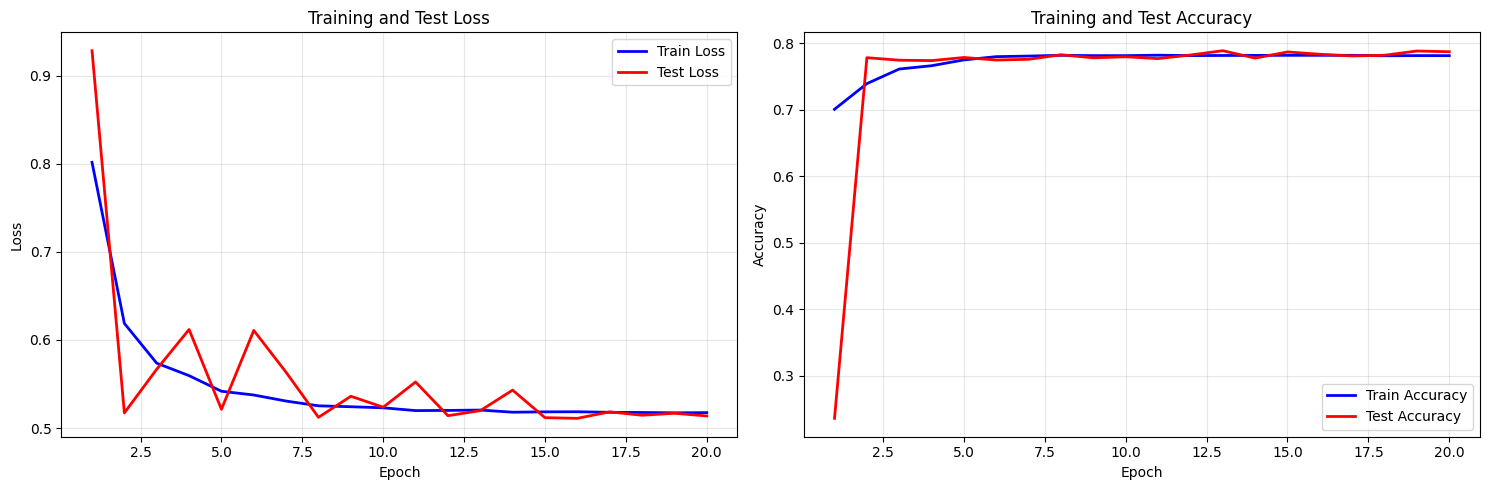

Final Train Accuracy: 0.7813
Final Test Accuracy: 0.7872


In [84]:
################################################################################
#                             Hyperparameters                                 #
# You can modify these hyperparameters to see how they affect the accuracy    #
################################################################################
model = LogisticRegressionWeightDecay(lr=1e-2, input_dim=106, hidden_dim=200, output_dim=1, weight_decay=1e-2)
trainer = Trainer(model, trainloader, testloader, max_epochs=20, log_interval=5)
trainer.train()
trainer.plot()

## Now we try optimize with SGDM
You might find out that the training result will heavily rely on a good learning rate, which might cost us a lot of time to try out.
SGDM works better because it avoids getting stuck in local minima.  
![](https://miro.medium.com/v2/resize:fit:494/format:webp/1*tbRXwsHwo9WPx5xTcZDX_A.png)

In [79]:
class LogisticRegressionMomentum(LogisticRegressionWeightDecay):
    def __init__(self, lr, input_dim, hidden_dim, output_dim, weight_decay=1e-4, momentum=0.5):
        '''
        Initialize the learning rate and momentum

        New Arguments:
        momentum -- float, momentum factor (0 < momentum < 1) for the optimizer.
        '''
        super().__init__(lr, input_dim, hidden_dim, output_dim, weight_decay=weight_decay)
        self.momentum = momentum
        self.wv = [] #store velocity for weights in each LinearLayer
        self.bv = [] #store velocity for bias in each LinearLayer
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                self.wv.append(torch.zeros_like(layer.w))
                self.bv.append(torch.zeros_like(layer.b))
    def optimize(self):
        '''
        Update the weights and bias using the gradients stored in each layer.
        '''
        ########################################################################
        #                           Your code there                            #
        ########################################################################
        linear_layer_idx = 0
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                self.wv[linear_layer_idx] = self.momentum * self.wv[linear_layer_idx] + self.lr * layer.dw
                layer.w -= self.wv[linear_layer_idx]
                self.bv[linear_layer_idx] = self.momentum * self.bv[linear_layer_idx] + self.lr * layer.db
                layer.b -= self.bv[linear_layer_idx]

                linear_layer_idx += 1
        ########################################################################
        #                           End of your code                           #
        ########################################################################














































































































































































































































































Epoch 1/20: 100%|██████████| 255/255 [00:01<00:00, 178.78it/s, loss=0.519]













































































































































































































































































Epoch 2/20: 100%|██████████| 255/255 [00:01<00:00, 182.20it/s, loss=0.563]













































































































































































































































































Epoch 5/20: 100%|██████████| 255/255 [00:01

Epoch: 5 	Train Loss: 0.533840 	Train Acc: 0.782501 	Test Acc: 0.236226 	Test Loss: 0.793708


Epoch 10/20: 100%|██████████| 255/255 [00:01<00:00, 213.17it/s, loss=0.63] 


Epoch: 10 	Train Loss: 0.526824 	Train Acc: 0.783391 	Test Acc: 0.791966 	Test Loss: 0.569871


Epoch 15/20: 100%|██████████| 255/255 [00:01<00:00, 222.42it/s, loss=0.547]


Epoch: 15 	Train Loss: 0.516684 	Train Acc: 0.790516 	Test Acc: 0.795283 	Test Loss: 0.523553


Epoch 20/20: 100%|██████████| 255/255 [00:01<00:00, 223.93it/s, loss=0.557]


Epoch: 20 	Train Loss: 0.514787 	Train Acc: 0.789994 	Test Acc: 0.793932 	Test Loss: 0.540342


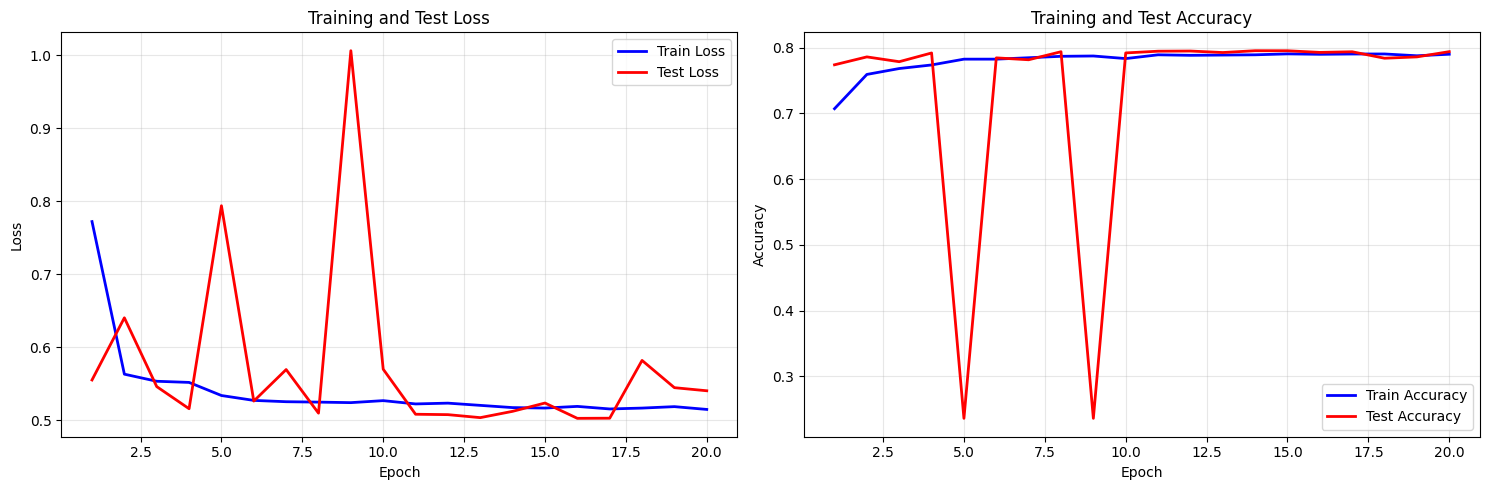

Final Train Accuracy: 0.7900
Final Test Accuracy: 0.7939


In [80]:
################################################################################
#                             Hyperparameters                                 #
# You can modify these hyperparameters to see how they affect the accuracy    #
################################################################################
model = LogisticRegressionMomentum(lr=1e-2, input_dim=106, hidden_dim=200, output_dim=1, weight_decay=1e-2, momentum=0.5)
trainer = Trainer(model, trainloader, testloader, max_epochs=20, log_interval=5)
trainer.train()
trainer.plot()

## Bonus --- Optimize with adamW (3 points)：
![](https://ml-explained.com/articles/adamw-explained/adamw.png)

In [81]:
class LogisticRegressionAdamW(LogisticRegressionWeightDecay):
    def __init__(self, lr, input_dim, hidden_dim, output_dim, weight_decay=1e-4, beta1=0.9, beta2=0.999, epsilon=1e-8):
        '''
        Initialize the learning rate and Adam optimizer parameters

        New Arguments:
        beta1 -- float, Exponential decay rate for the first moment estimates.
        beta2 -- float, Exponential decay rate for the second moment estimates.
        epsilon -- float, Small constant for numerical stability.
        '''
        super().__init__(lr, input_dim, hidden_dim, output_dim, weight_decay=weight_decay)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon # Prevent division by zero
        self.mw = [] #store first moment for weights in each LinearLayer
        self.vw = [] #store second moment for weights in each LinearLayer
        self.mb = [] #store first moment for bias in each LinearLayer
        self.vb = [] #store second moment for bias in each LinearLayer
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                self.mw.append(torch.zeros_like(layer.w))
                self.vw.append(torch.zeros_like(layer.w))
                self.mb.append(torch.zeros_like(layer.b))
                self.vb.append(torch.zeros_like(layer.b))
        self.t = 0 # timestep
    def optimize(self):
        '''
        Update the weights and bias using the gradients stored in each layer.
        '''
        self.t += 1
        ########################################################################
        #                           Your code there                            #
        ########################################################################
        linear_layer_idx = 0
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                grad_w = layer.dw 
                layer.w -= self.lr * self.weight_decay * layer.w 
                self.mw[linear_layer_idx] = self.beta1 * self.mw[linear_layer_idx] + (1 - self.beta1) * grad_w
                self.vw[linear_layer_idx] = self.beta2 * self.vw[linear_layer_idx] + (1 - self.beta2) * (grad_w ** 2)
                mw_hat = self.mw[linear_layer_idx] / (1 - self.beta1 ** self.t)
                vw_hat = self.vw[linear_layer_idx] / (1 - self.beta2 ** self.t)
                layer.w -= self.lr * mw_hat / (torch.sqrt(vw_hat) + self.epsilon)
                grad_b = layer.db
                self.mb[linear_layer_idx] = self.beta1 * self.mb[linear_layer_idx] + (1 - self.beta1) * grad_b
                self.vb[linear_layer_idx] = self.beta2 * self.vb[linear_layer_idx] + (1 - self.beta2) * (grad_b ** 2)
                mb_hat = self.mb[linear_layer_idx] / (1 - self.beta1 ** self.t)
                vb_hat = self.vb[linear_layer_idx] / (1 - self.beta2 ** self.t)
                layer.b -= self.lr * mb_hat / (torch.sqrt(vb_hat) + self.epsilon)
                linear_layer_idx += 1
        ########################################################################
        #                           End of your code                           #
        ########################################################################

Epoch 5/20: 100%|██████████| 255/255 [00:01<00:00, 214.43it/s, loss=0.548]


Epoch: 5 	Train Loss: 0.509343 	Train Acc: 0.793127 	Test Acc: 0.794607 	Test Loss: 0.505585


Epoch 10/20: 100%|██████████| 255/255 [00:01<00:00, 175.93it/s, loss=0.461]


Epoch: 10 	Train Loss: 0.503378 	Train Acc: 0.792850 	Test Acc: 0.794669 	Test Loss: 0.503785


Epoch 15/20: 100%|██████████| 255/255 [00:01<00:00, 184.91it/s, loss=0.645]


Epoch: 15 	Train Loss: 0.501662 	Train Acc: 0.793465 	Test Acc: 0.795037 	Test Loss: 0.498295


Epoch 20/20: 100%|██████████| 255/255 [00:01<00:00, 183.00it/s, loss=0.659]


Epoch: 20 	Train Loss: 0.503259 	Train Acc: 0.793280 	Test Acc: 0.795406 	Test Loss: 0.495355


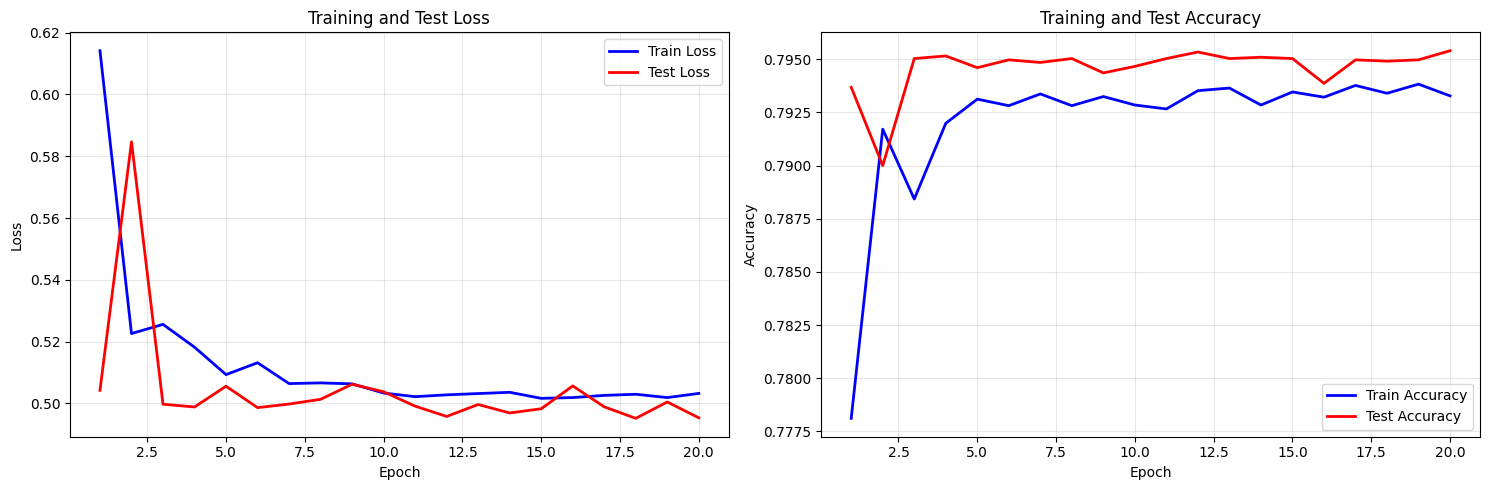

Final Train Accuracy: 0.7933
Final Test Accuracy: 0.7954


In [82]:
#Training with AdamW optimizer
################################################################################
#                             Hyperparameters                                 #
# You can modify these hyperparameters to see how they affect the accuracy    #
################################################################################
model = LogisticRegressionAdamW(lr=1e-2, input_dim=106, hidden_dim=200, output_dim=1, weight_decay=1e-4, beta1=0.9, beta2=0.999, epsilon=1e-8)
trainer = Trainer(model, trainloader, testloader, max_epochs=20, log_interval=5)
trainer.train()
trainer.plot()